In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczema_285.jpg
/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczema_1.jpg
/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczema_217.jpg
/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczema_380.jpg
/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczema_198.jpg
/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczema_353.jpg
/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczema_145.jpg
/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczema_328.jpg
/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczema_326.jpg
/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczema_281.jpg
/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Eczema/Eczem

In [2]:
import cv2
import numpy as np
import os

image_folder = '/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Keratosis'  # Change the path to your image folder
image_size = (128, 128)

def load_images(folder):
    images = []
    labels = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.resize(img, image_size)
            images.append(img)
            labels.append(filename)  # Adjust based on dataset
    return np.array(images), labels

X, y = load_images(image_folder)
print(f"Loaded {len(X)} images.")

Loaded 399 images.


In [3]:
import numpy as np
import os
import cv2
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


def load_data(directory, img_size=(150,150)):
    X, y = [], []
    
   
    if not os.path.isdir(directory):
        raise NotADirectoryError(f"'{directory}' is not a directory. Please provide a folder path.")

    labels = sorted(os.listdir(directory)) 

    for label_idx, label in enumerate(labels):
        class_dir = os.path.join(directory, label)

       
        if not os.path.isdir(class_dir):
            continue

        for image_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, image_name)

           
            if not img_path.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img = cv2.imread(img_path)
            img = cv2.resize(img, img_size) 
            X.append(img)
            y.append(label_idx)  # Numeric label for class

    X = np.array(X) / 255.0  # Normalize images
    y = np.array(y)
    y = to_categorical(y, num_classes=len(labels))  
    
    return X, y

dataset_path = "/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions"
X, y = load_data(dataset_path)  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(6, activation='softmax'))  

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)


history = model.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.1,
    batch_size=32
)


test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 340ms/step - accuracy: 0.1627 - loss: 1.7932 - val_accuracy: 0.2240 - val_loss: 1.7908
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.1679 - loss: 1.7883 - val_accuracy: 0.3021 - val_loss: 1.7816
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.2457 - loss: 1.7231 - val_accuracy: 0.3021 - val_loss: 1.6734
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.3018 - loss: 1.6224 - val_accuracy: 0.3958 - val_loss: 1.5773
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.3565 - loss: 1.5359 - val_accuracy: 0.4427 - val_loss: 1.4833
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.3796 - loss: 1.4714 - val_accuracy: 0.4583 - val_loss: 1.4245
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.3862 - loss: 1.4334 - val_accuracy: 0.5052 - val_loss: 1.3622
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.4797 - loss: 1.3114 - val_accuracy: 0.5052 -

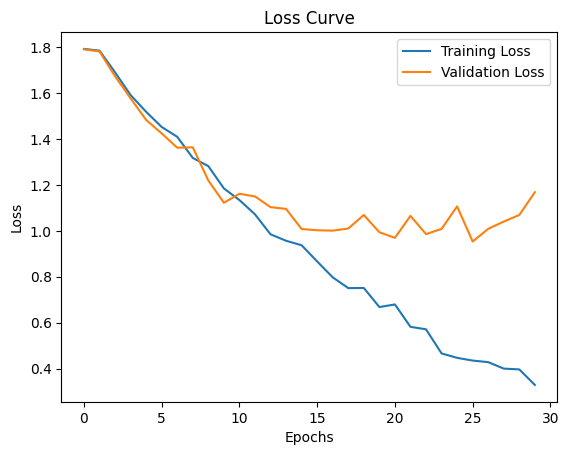

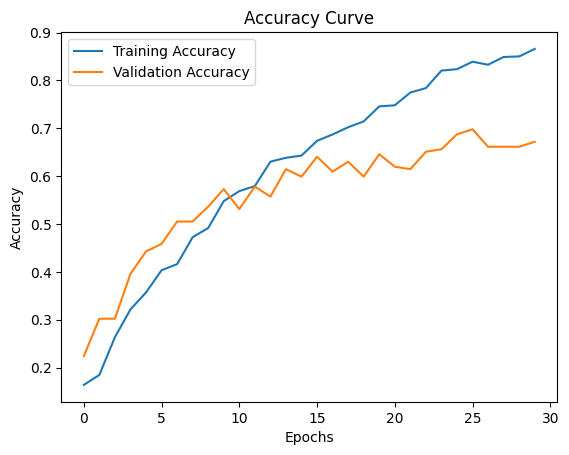

In [4]:
import matplotlib.pyplot as plt


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()


plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')
plt.show()


In [5]:

model_save_path = "/kaggle/working/augmented-skin-conditions-image-dataset/Skin_Conditions.h5"
model.save(model_save_path)
print(f" Model saved at: {model_save_path}")
import os
from tensorflow.keras.models import load_model


model_path = "/kaggle/working/augmented-skin-conditions-image-dataset/Skin_Conditions.h5"


if os.path.exists(model_path):
    model = load_model(model_path)
    print(" Model loaded successfully!")
else:
    raise FileNotFoundError(f" Error: Model file not found at {model_path}. Train and save the model first.")


 Model saved at: /kaggle/working/augmented-skin-conditions-image-dataset/Skin_Conditions.h5
 Model loaded successfully!


In [6]:
import cv2
import numpy as np
import os

def preprocess_image(image_path, img_size=(150, 150)):
    """
    Reads and preprocesses an image for model prediction.

    Steps:
    1. Load the image from the given path.
    2. Check if the image is loaded successfully.
    3. Convert BGR to RGB format.
    4. Resize the image to the required model input size.
    5. Normalize pixel values (scale between 0 and 1).
    6. Expand dimensions to match the model’s expected input shape.

    Parameters:
    - image_path (str): Path to the image file.
    - img_size (tuple): Target size (width, height).

    Returns:
    - Preprocessed image as a NumPy array.
    """
    
   
    img = cv2.imread(image_path)
    
    
    if img is None:
        raise FileNotFoundError(f" Error: Unable to load image from '{image_path}'. Check the file path!")

    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    
    img = cv2.resize(img, img_size)

    
    img = img.astype(np.float32) / 255.0  

    
    img = np.expand_dims(img, axis=0)

    return img


image_path = "/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Rosacea/Rosacea_125.jpg"  


try:
    preprocessed_img = preprocess_image(image_path)
    print(" Image Preprocessed Successfully!")
    print("Preprocessed Image Shape:", preprocessed_img.shape)  
except FileNotFoundError as e:
    print(e)



 Image Preprocessed Successfully!
Preprocessed Image Shape: (1, 150, 150, 3)


In [7]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np

# Load the Model
model_path = "/kaggle/working/augmented-skin-conditions-image-dataset/Skin_Conditions.h5" 
model = load_model(model_path)

# Check model input shape
print("Model Input Shape:", model.input_shape)

# Class Labels
class_labels = {
    "disease": ["Melanoma", "Psoriasis", "Rosacea"],
    "problem": ["Acne", "Keratosis", "Eczema"]
}

def preprocess_image(image_path):
    """
    Preprocess the input image for model prediction.
    """
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Reshape if necessary (check model input shape)
    expected_shape = model.input_shape[1:] 
    if img_array.shape[1:] != expected_shape:
        img_array = tf.image.resize(img_array, (expected_shape[0], expected_shape[1]))
    
    return img_array

def apply_temperature_scaling(predictions, temperature=3.0):
    """
    Apply temperature scaling to reduce confidence scores.
    """
    predictions = np.asarray(predictions)
    scaled_preds = np.exp(predictions / temperature) / np.sum(np.exp(predictions / temperature), axis=-1, keepdims=True)
    return scaled_preds

def classify_disease(image_path):
    """
    Classifies the given skin image into a specific disease (Melanoma, Psoriasis, or Rosacea).
    """
    img_array = preprocess_image(image_path)
    preds = model.predict(img_array)
    scaled_preds = apply_temperature_scaling(preds)

    # Only consider diseases (Class Index 0 to 2)
    disease_preds = scaled_preds[0][:3]
    class_index = np.argmax(disease_preds)
    confidence = np.max(disease_preds)

    predicted_class = class_labels["disease"][class_index]
    return "Disease", predicted_class, confidence

def classify_problem(image_path):
    """
    Classifies the given skin image into a specific problem (Acne, Keratosis, or Eczema).
    """
    img_array = preprocess_image(image_path)
    preds = model.predict(img_array)
    scaled_preds = apply_temperature_scaling(preds)

    # Only consider problems (Class Index 3 to 5)
    problem_preds = scaled_preds[0][3:]
    class_index = np.argmax(problem_preds)
    confidence = np.max(problem_preds)

    predicted_class = class_labels["problem"][class_index]
    return "Problem", predicted_class, confidence

# Example Usage
image_path = "/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions/Rosacea/Rosacea_125.jpg"
category, predicted_class, confidence = classify_disease(image_path)
print(f"Disease Prediction: {predicted_class} ({category})")
print(f"Confidence Score: {confidence:.2f}")

category, predicted_class, confidence = classify_problem(image_path)
print(f"Problem Prediction: {predicted_class} ({category})")
print(f"Confidence Score: {confidence:.2f}")


Model Input Shape: (None, 150, 150, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Disease Prediction: Rosacea (Disease)
Confidence Score: 0.16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Problem Prediction: Acne (Problem)
Confidence Score: 0.20
